# Create AAV6-ML plots for report for internship in AG Grimm
Author: Kolja Hildenbrand

Created: 01/04/2026

## 1. Packages

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import re
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import product
from matplotlib_venn import venn2

## 2. Create Paths

In [2]:
#---------------------------------
#---------------------------------
#---------------------------------

#general Path

general_dir = Path('/Users/kollybook/Library/Mobile Documents/com~apple~CloudDocs/Kolja_Hildenbrand/Uni/Master_Infectious_Diseases/Grimm_internship/Report_Grimm/Data') # <----- Hier den Server Path anpassen
os.makedirs(general_dir, exist_ok=True)

#---------------------------------
#---------------------------------
#---------------------------------

# Path for NGS data
NGS_dir = general_dir/'NGS_data'
os.makedirs(NGS_dir, exist_ok=True)

# Path for tables
tables_dir = general_dir/'tables'
os.makedirs(tables_dir, exist_ok=True)

#Path for plots
figures_dir = general_dir/'figures'
os.makedirs(figures_dir, exist_ok=True)

## 3. Define Functions


### 3.1. Helper functions

In [3]:
# read csv files
def read_csv_file (path, file_name):
    df = pd.read_csv(path / f"{file_name}.csv")
    return df

In [4]:
# extract list information from table
def extract_info(table, *columns):
    results = []
    
    for col in columns:
        if col not in table.columns:
            raise ValueError(f"Column '{col}' not found in table")
        
        unique_vals = (
            table[col]
            .dropna()
            .unique()
            .tolist()
        )
        
        results.append(sorted(unique_vals))
    
    return tuple(results)

In [5]:
def sort_file_names (name_list):
    FILE_NAMES = {
        "gDNA": {
            "heart": {"biological": [], "technical": []},
            "liver": {"biological": [], "technical": []}
        },
        "cDNA": {
            "heart": {"biological": [], "technical": []},
            "liver": {"biological": [], "technical": []}
        }
    }
    
    for name in name_list:
        parts = name.split("_")
        n_parts = len(parts)
    
        # ext type
        if name.startswith("gDNA"):
            dna = "gDNA"
        elif name.startswith("cDNA"):
            dna = "cDNA"
        else:
            continue
    
        # Tissue 
        tissue = parts[1]
    
        if tissue not in ["heart", "liver"]:
            continue  
    
        # bio or tech
        if n_parts == 3:
            category = "biological"
        elif n_parts == 4:
            category = "technical"
        else:
            continue
    
        FILE_NAMES[dna][tissue][category].append(name)

    return FILE_NAMES 

### 3.2. Script Functions

#### 3.2.1. Function to create Histogram of sample proportion vs input proportion

In [6]:
# Function to create Histogram of sample proportion vs input proportion

def distribution_histogram (
    table, 
    tissue, 
    extraction, 
    column, 
    replicate,
    no_pseudo = False,
    legend = True, 
    title = True, 
    save=False, 
    output_path=None, 
    file_name = None
):
    
    if replicate == "biological":
        legend_name = "Data"
    elif replicate == "technical":
        legend_name = "Sample"
    else:
        raise ValueError("Replicate must be 'biological' or 'technical'")
   
    # -----------------------------
    # Prepare input library
    # -----------------------------       
    input_library = dict_library[tissue].copy()
    input_library[legend_name] = 'input_library'
    
    # -----------------------------
    # Prepare selected sample data
    # -----------------------------    
    df = table[
        (table["Replicate"] == replicate) &
        (table["Tissue"] == tissue) &
        (table["Extraction_type"] == extraction)
    ][['AA_sequence', 'Sample', 'Mouse_ID', 'Proportion', 'Cum_prop', 'Log2_enrichment', 'Pseudo']].copy()
    
    # usage of pseudo variants or not
    if no_pseudo:
        df = df[df['Pseudo'] == 0]
        
    # for biological: use Mouse_ID as grouping name
    if replicate == "biological":
        df = df.rename(columns={"Mouse_ID": "Data"})
    
    # concat input library + samples
    df = pd.concat([input_library, df], axis=0, ignore_index=True)

    # keep valid values only
    df = df[df[column].notna()].copy()

    # define x-range
    x_min = table[column].min() 
    x_max = table[column].max()

    bin_edges = np.logspace(np.log10(x_min), np.log10(x_max), 100)
   
    # -----------------------------
    # Styling
    # -----------------------------
    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10
    })

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    # -----------------------------
    # Define colors (mouse different blue colours and library red)
    # -----------------------------
    mouse_palette = {
        "f1": "#9ECAE1",   #blau
        "f2": "#6BAED6",
        "f3": "#3182BD",
        "m1": "#D4B9DA",   # violett
        "m2": "#C994C7",   
        "m3": "#88419D"
    }

    input_color = "#BDBDBD"

    # -----------------------------
    # Plot input library first (background)
    # -----------------------------
    input_sub = df[df[legend_name] == "input_library"]
    if not input_sub.empty:
        ax.hist(
            input_sub[column],
            bins=bin_edges,
            alpha=0.8,
            color=input_color,
            label="input_library",
            edgecolor="none",
            zorder=1
        )
        
    # -----------------------------
    # Plot mice on top
    # -----------------------------
    present_data = [x for x in df[legend_name].unique() if x != "input_library"]

    # keep biological mouse order if possible
    ordered_data = [x for x in MOUSE_ID if x in present_data] + [x for x in present_data if x not in MOUSE_ID]

    for data in ordered_data:
        sub = df[df[legend_name] == data]

        color = mouse_palette.get(data, "#4C72B0")  # fallback blue

        ax.hist(
            sub[column],
            bins=bin_edges,
            alpha=0.35,
            color=color,
            label=data,
            edgecolor="none",
            zorder=2
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(x_min, x_max)

    ax.set_xlabel("Variant proportion in sample")
    ax.set_ylabel("Number of AA sequences")

    if title:
        ax.set_title(f"{extraction} {tissue}: distribution of AA-sequence proportions")

    if legend:
        ax.legend(title=legend_name, frameon=False, ncol=2, loc="upper right")

    sns.despine()
    plt.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        os.makedirs(output_path, exist_ok=True)
        if file_name is None:
            file_name = f"Histogram_{column}_distribution_{extraction}_{tissue}.png"
        fig.savefig(os.path.join(output_path, file_name), dpi=600, bbox_inches="tight")

    plt.show()

#### 3.2.2. Distribution ecdf for Proportion and Log2_enrichment

In [21]:
def distribution_ecdf(
    table,
    tissue,
    extraction,
    column,
    replicate,
    no_pseudo = False,
    legend=True,
    title=True,
    save=False,
    output_path=None,
    file_name=None
):
    
    if replicate == "biological":
        legend_name = "Data"
    elif replicate == "technical":
        legend_name = "Sample"
    else:
        raise ValueError("Replicate must be 'biological' or 'technical'")

    # -----------------------------
    # Prepare input library
    # -----------------------------
    input_library = dict_library[tissue].copy()
    input_library[legend_name] = "input_library"

    # -----------------------------
    # Prepare selected sample data
    # -----------------------------
    df_sample = table[
        (table["Replicate"] == replicate) &
        (table["Tissue"] == tissue) &
        (table["Extraction_type"] == extraction)
    ][["AA_sequence", "Sample", "Mouse_ID", f'{column}', "Pseudo"]].copy()
    
    # usage of pseudo variants or not
    if no_pseudo:
        df_sample = df_sample[df_sample['Pseudo'] == 0]
        
    if replicate == "biological":
        df_sample = df_sample.rename(columns={"Mouse_ID": "Data"})

    if column == 'Proportion':
        df_sample = df_sample[df_sample['Pseudo'] == 0]

    # -----------------------------
    # Concat input + selected samples
    # -----------------------------
    df = pd.concat([input_library, df_sample], axis=0, ignore_index=True)

    # keep valid values only
    df = df[df[column].notna()].copy()

    # define x-range from filtered data
    x_min = df[column].min()
    x_max = df[column].max()

    # -----------------------------
    # Styling
    # -----------------------------
    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10
    })

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    # -----------------------------
    # Define colors
    # -----------------------------
    color_palette = {
        "input_library": "#BDBDBD",  # grey
        "f1": "#9ECAE1",             # blue shades
        "f2": "#6BAED6",
        "f3": "#3182BD",
        "m1": "#D4B9DA",             # violet shades
        "m2": "#C994C7",
        "m3": "#88419D"
    }

    # -----------------------------
    # Define plotting order
    # -----------------------------
    present_samples = [x for x in df[legend_name].dropna().unique() if x != "input_library"]

    preferred_order = ["f1", "f2", "f3", "m1", "m2", "m3"]
    ordered_samples = [x for x in preferred_order if x in present_samples] + \
                      [x for x in present_samples if x not in preferred_order]

    sample_order = ["input_library"] + ordered_samples

    # -----------------------------
    # Plot ECDFs
    # -----------------------------
    for data_name in sample_order:
        sub = df[df[legend_name] == data_name].copy()
        if sub.empty:
            continue

        color = color_palette.get(data_name, "#4C72B0")

        # input in background, full opacity
        if data_name == "input_library":
            alpha_val = 1.0
            lw = 2.2
            z = 1
        else:
            alpha_val = 0.5
            lw = 2.0
            z = 2

        sns.ecdfplot(
            data=sub,
            x=column,
            ax=ax,
            color=color,
            alpha=alpha_val,
            linewidth=lw,
            label=data_name,
            zorder=z
        )

    # -----------------------------
    # Reference lines
    # -----------------------------
    mean_val = df_sample[column].mean()

    # for proportion: only mean line
    # for log2_enrichment: zero line + mean line
    line_handles = []

    if column.startswith("Log2"):
        line_zero = ax.axvline(
            0,
            linestyle="--",
            linewidth=1.5,
            color="red",
            alpha=0.9,
            label="No enrichment = 0"
        )
        line_handles.append(line_zero)

    line_mean = ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.9,
        label=f"Mean = {mean_val:.2e}" if column == "Proportion" else f"Mean = {mean_val:.2f}"
    )
    line_handles.append(line_mean)

    # -----------------------------
    # Axes
    # -----------------------------
    ax.set_xlim(x_min, x_max)

    if column == "Proportion":
        ax.set_xscale("log")
        ax.set_xlabel("Variant proportion")
        ylab = "Cumulative fraction of AA sequences"
        title_text = f"{extraction} {tissue}\nCumulative distribution of AA-sequence proportions"
    else:
        ax.set_xlabel(f"Variant {column}")
        ylab = "Cumulative fraction of AA sequences"
        title_text = f"{extraction} {tissue}\nCumulative distribution of {column}"

    ax.set_ylabel(ylab)

    if title:
        ax.set_title(title_text)

    # -----------------------------
    # Legend
    # -----------------------------
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))  # remove duplicates, preserve last occurrence
        ax.legend(
            unique.values(),
            unique.keys(),
            title= legend_name,
            loc="lower right",
            frameon=False,
            ncol=2
        )

    sns.despine()
    plt.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        os.makedirs(output_path, exist_ok=True)
        if file_name is None:
            file_name = f"ECDF_{column}_{extraction}_{tissue}_{replicate}.png"
        fig.savefig(os.path.join(output_path, file_name), dpi=600, bbox_inches="tight")

    plt.show()

#### 3.2.3. Venn2 Diagram of top proportion between sample and input

In [8]:
def venn2_ntop_AA (table, tissue, extraction, n_top, title = True, save = False, output_path = None):

    # select samples I want to compare
    sample = ((table [
        (table['Tissue'] == tissue) &
        (table['Extraction_type'] == extraction)
    ][["AA_sequence", 'Proportion']].sort_values('Proportion', ascending = False)).head(n_top)).copy()
    
    
    #select
    input_library = ((dict_library[tissue][["AA_sequence", 'Proportion']].sort_values('Proportion', ascending = False)).head(n_top)).copy()

    plt.figure(figsize=(7,4))
    venn2([set(input_library["AA_sequence"]), set(sample["AA_sequence"])], set_labels=("Input library", f"{tissue} {extraction} pooled"))

    if title:
        plt.title(f"{extraction} {tissue}\nOverlap of top {n_top} proportion AA variants")
    
    plt.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        os.makedirs(output_path, exist_ok=True)
        plt.savefig(output_path/f'Venn2_{extraction}_{tissue}_proportion_top_{n_top}', dpi=600, bbox_inches="tight")

    
    plt.show()

#### 3.2.4. Rank shift proportion input library -> gDNA -> cDNA

#### 3.3.1. Violin plot (with box plot)

In [9]:
def violin_enrichment_per_type_test(
    table,
    order=None,
    n_samples=6,
    violin = False,
    scatter_dots = False,
    box = False,
    save=False,
    file_name=None,
    output_path=None
):
    if order is None:
        order = ["gDNA_liver", "cDNA_liver", "gDNA_heart", "cDNA_heart"]

    df = table.copy()
    df["Type"] = df["Extraction_type"] + "_" + df["Tissue"]

    df = df.loc[
        (df['n_tissue_samples_present'] >= n_samples)
        ]

    df = df[["AA_sequence", "Type", "Log2_enrichment"]].copy()
    df = df[df["Type"].isin(order)].copy()

    palette = {
        "gDNA_liver": "#4C5C68",
        "cDNA_liver": "#5DA5DA",
        "gDNA_heart": "#6B6D9C",
        "cDNA_heart": "#B276B2",
    }

    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

    fig, ax = plt.subplots(figsize=(7, 4))

    if violin:
        sns.violinplot(
            data=df,
            x="Type",
            y="Log2_enrichment",
            hue="Type",
            order=order,
            hue_order=order,
            palette=palette,
            dodge=False,
            legend=False,
            cut=0,
            inner='quartile',
            ax=ax
        )

        
    if box:
        sns.boxplot(
            data=df,
            x="Type",
            y="Log2_enrichment",
            order=order,
            width=0.4,
            showcaps=False,
            showfliers=False,
            boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.0, "zorder": 3},
            whiskerprops={"linewidth": 1.0, "zorder": 3},
            medianprops={"color": "black", "linewidth": 1.2, "zorder": 4},
            ax=ax
        )

    if scatter_dots:
        sns.stripplot(
        data=df.sample(min(len(df), 5000), random_state=1),
        x="Type",
        y="Log2_enrichment",
        order=order,
        color="black",
        alpha=0.2,
        size=1.5,
        jitter=0.22,
        ax=ax
        )
    
    ax.axhline(0, color="0.5", linestyle="--", linewidth=1)

    ax.set_ylabel("Log2 enrichment")

    ax.set_title(f"Log2 comparison of samples\nIncluded variants are present in at least {n_samples} samples") 

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)

    sns.despine(ax=ax)
    fig.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        os.makedirs(output_path, exist_ok=True)
        if file_name is None:
            file_name = f"Log2_enrichment_comparison_variants_in_mind_{n_samples}_samples.png"
        fig.savefig(os.path.join(output_path, file_name), dpi=600, bbox_inches="tight")

    plt.show();

#### 3.3.2. KDE distribution for Chapter 3
for Proportion use 'df["log_value"] = np.log10(df[column])'

In [10]:
# KDE plot for enrichment
def kde_gDNA_vs_cDNA(
    table, 
    tissue, 
    column,
    n_samples = 6,
    save = False,
    file_name = None,
    output_path = None
    
):
    
    df = table.copy()
    df = df[['AA_sequence', 'Tissue', 'Extraction_type', column, 'Log2_enrich_gDNA_to_cDNA', 'n_tissue_samples_present']]
    df = df.loc[
        (df['Tissue'] == tissue)
        ]
    

    df = df.loc[
    (df['n_tissue_samples_present'] >= n_samples)
    ]

    gDNA_values = df[df['Extraction_type'] == 'gDNA']
    cDNA_values = df[df['Extraction_type'] == 'cDNA']
    gDNA_variants = len(gDNA_values['AA_sequence'])
    cDNA_variants = len(cDNA_values['AA_sequence'])
    
    gDNA_color = "#4C5C68"
    cDNA_color = "#5DA5DA"

    plt.figure(figsize=(6, 4))

    sns.kdeplot(
        data=gDNA_values,
        x=column,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        color=gDNA_color,
        label=f"{gDNA_variants} gDNA variants"
    )

    sns.kdeplot(
        data=cDNA_values,
        x=column,
        fill=True,
        alpha=0.4,
        linewidth=1.5,
        color=cDNA_color,
        label=f"{cDNA_variants} cDNA variants"
    )
    if column == 'Log2_enrichment':
        plt.axvline(0, color="0.5", linestyle="--", linewidth=1)

    if column == 'Proportion':
        plt.xscale('log')

    plt.xlim(-10, 10)

    plt.title(f'{tissue}\nPresent in mind. {n_samples} samples', fontsize = 12)
    plt.xlabel(column)
    plt.ylabel("Density")
    

    plt.legend(frameon=False)

    sns.despine()
    plt.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        os.makedirs(output_path, exist_ok=True)
        if file_name is None:
            file_name = f"KDE_log_enrichment_{tissue}_gDNA_vs_cDNA_in_mind_{n_samples}_samples.png"
        plt.savefig(os.path.join(output_path, file_name), dpi=600, bbox_inches="tight")
    
    plt.show()
    

#### 3.3.3. Venn2plot with top 10000 Log2_enrichment¶

In [142]:
def venn2_top_enrichment_variants (table, tissue, n_top, n_samples = 0, title = True, save = False, output_path = None, file_name = None):

    # select samples I want to compare
    sample = (table [
        (table['Tissue'] == tissue) &
        (table['n_tissue_samples_present'] >= n_samples)
        ][["AA_sequence", 'Log2_enrichment', 'Extraction_type', 'n_tissue_samples_present']]).copy()

    cDNA_samples = sample[sample['Extraction_type'] == 'cDNA'].sort_values('Log2_enrichment', ascending = False).head(n_top).copy()
    cDNA_number = cDNA_samples.shape[0]
    if cDNA_number <= n_top:
        gDNA_samples = sample[sample['Extraction_type'] == 'gDNA'].sort_values('Log2_enrichment', ascending = False).head(cDNA_number).copy()
    else:
        gDNA_samples = sample[sample['Extraction_type'] == 'gDNA'].sort_values('Log2_enrichment', ascending = False).head(n_top).copy()
    
    # get AA_variants in set to compare them

    plt.figure(figsize=(7,4))
    venn2([set(gDNA_samples["AA_sequence"]), set(cDNA_samples["AA_sequence"])], set_labels=(f"gDNA {tissue}", f"cDNA {tissue}"))

    # set title
    if title:
        if cDNA_number <= n_top:
            plt.title(f"{tissue}\nOverlap of top {cDNA_number} Log2_enrichment AA variants for gDNA and cDNA\nIn min. {n_samples}/6 samples")
        else:
            plt.title(f"{tissue}\nOverlap of top {n_top} Log2_enrichment AA variants for gDNA and cDNA\nIn min. {n_samples}/6 samples")
    
    plt.tight_layout()

    # save file
    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        os.makedirs(output_path, exist_ok=True)
        if file_name is None:
            file_name = f"Venn2_of_top_{cDNA_number}_log2_enrich_variants_in_{tissue}_gDNA_vs_cDNA_in_min_{n_samples}_samples.png"
        plt.savefig(os.path.join(output_path, file_name), dpi=600, bbox_inches="tight")

    plt.show()

#### 3.3.4. Diagram of Venn2 overlap in %

In [295]:
def Diagram_for_overlap_log2 (table, tissue, n_samples = 0, title = True, save = False, output_path = None, file_name = None):

    # select samples I want to compare
    sample = (table [
        (table['Tissue'] == tissue) &
        (table['n_tissue_samples_present'] >= n_samples)
        ][["AA_sequence", 'Log2_enrichment', 'Extraction_type', 'n_tissue_samples_present']]).copy()

    cDNA_samples = list(sample[sample['Extraction_type'] == 'cDNA'].sort_values('Log2_enrichment', ascending = False)['AA_sequence'])
    cDNA_number = len(cDNA_samples)
    
    gDNA_samples = list(sample[sample['Extraction_type'] == 'gDNA'].sort_values('Log2_enrichment', ascending = False)['AA_sequence'])



    log2_list = 2 ** np.arange(1, int(np.log2(cDNA_number)) + 1)
    plot_values = []
    
    for i in log2_list:
        cDNA_top = cDNA_samples[:i]
        gDNA_top = gDNA_samples[:i]

        overlap_fraction = len(set(cDNA_top) & set(gDNA_top)) / i
        plot_values.append(overlap_fraction * 100)

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(log2_list, plot_values, marker = 'o', linewidth=1.5)

    ax.set_xscale("log", base=2)
    ax.set_xlabel("Top N variants")
    ax.set_ylabel("Fractional overlap [%]")
    ax.set_ylim(0, np.max(plot_values)*1.1)

    if title:
        ax.set_title(f"{tissue}\nTop-N overlap of gDNA and cDNA variants\nVariant present in mind {n_samples}/6 samples")

    plt.tight_layout()

    if save:
        import os
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        os.makedirs(output_path, exist_ok=True)
        if file_name is None:
            file_name = f"overlap_log2_{tissue}_in_min_{n_samples}_samples.png"
        fig.savefig(os.path.join(output_path, file_name), dpi=300, bbox_inches="tight")

    plt.show()



In [341]:
def Diagram_for_overlap_log2(
    table,
    tissues,
    n_samples=0,
    title=True,
    save=False,
    output_path=None,
    file_name=None
):
    
    color_map = {
        "liver": "blue",
        "heart": "red"
    }

    fig, ax = plt.subplots(figsize=(6, 4))

    all_plot_values = []

    for tissue in tissues:
        # Samples auswählen
        sample = table[
            (table["Tissue"] == tissue) &
            (table["n_tissue_samples_present"] >= n_samples)
        ][["AA_sequence", "Log2_enrichment", "Extraction_type", "n_tissue_samples_present"]].copy()

        cDNA_samples = list(
            sample[sample["Extraction_type"] == "cDNA"]
            .sort_values("Log2_enrichment", ascending=False)["AA_sequence"]
        )

        gDNA_samples = list(
            sample[sample["Extraction_type"] == "gDNA"]
            .sort_values("Log2_enrichment", ascending=False)["AA_sequence"]
        )

        # maximale gemeinsame Länge
        n_max = min(len(cDNA_samples), len(gDNA_samples))
        
        log2_list = list(2 ** np.arange(1, int(np.log2(n_max)) + 1))
        log2_list = sorted(set(log2_list + [n_max]))
        plot_values = []

        for i in log2_list:
            cDNA_top = cDNA_samples[:i]
            gDNA_top = gDNA_samples[:i]

            overlap_fraction = len(set(cDNA_top) & set(gDNA_top)) / i
            plot_values.append(overlap_fraction * 100)

        all_plot_values.extend(plot_values)


        ax.plot(
            log2_list,
            plot_values,
            marker="o",
            linewidth=1.5,
            color=color_map.get(tissue, None),
            label=tissue
        )

    ax.set_xscale("log", base=10)

    ax.set_xlabel("Top N variants")
    ax.set_ylabel("Overlap [%]")

    if all_plot_values:
        ax.set_ylim(0, max(all_plot_values) + 1.1)

    if title:
        if len(tissues) == 1:
            ax.set_title(
                f"{tissues[0]}\nTop-N overlap of gDNA and cDNA variants\n"
                f"Variant present in min. {n_samples}/6 samples"
            )
        else:
            ax.set_title(
                f"Top-N overlap of gDNA and cDNA variants\n"
                f"Variant present in min. {n_samples}/6 samples"
            )

    ax.legend(frameon=False)
    plt.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        os.makedirs(output_path, exist_ok=True)

        if file_name is None:
            tissue_string = "_".join(tissues)
            file_name = f"overlap_log2_{tissue_string}_in_min_{n_samples}_samples.png"

        fig.savefig(os.path.join(output_path, file_name), dpi=300, bbox_inches="tight")

    plt.show()

#### 3.3.5. Rankshift for log2_enrichment between gDNA and cDNA

pivot table umschreiben, damit ich die angaben für n_sample für c_DNA und g_DNA habe
reine pseudo also n_sample = 0 rot makieren
verschiedene werte für n_sample testen

In [366]:
def rank_shift_between_gDNA_and_cDNA (
    table, 
    tissue, 
    column, 
    n_samples = 0, 
    save = False, 
    output_dir = None, 
    file_name = None
):
    
    sample = (table [
            (table['Tissue'] == tissue)
            ][["AA_sequence", f'{column}_gDNA', f'{column}_cDNA']]).copy()
    
    sample = sample.fillna(0).copy()
    
    if column == 'Log2_enrichment':
        sample['Log2_enrich_gDNA_to_cDNA_cDNA'] = (table [
            (table['Tissue'] == tissue)
            ][['Log2_enrich_gDNA_to_cDNA_cDNA']]).copy()
        
        sample["rank_gDNA_to_cDNA"] = sample["Log2_enrich_gDNA_to_cDNA_cDNA"].rank(ascending=False, method="average")
    
    
    sample["rank_gDNA"] = sample[f'{column}_gDNA'].rank(ascending=False, method="average")
    sample["rank_cDNA"] = sample[f'{column}_cDNA'].rank(ascending=False, method="average")
    
    
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(7, 6))
    
    
    ax.scatter(
        sample["rank_gDNA"],
        sample["rank_cDNA"],
        s=5,
        alpha=0.25,
        color="#4C72B0",
        linewidths=0,
        label="Variant"
    )
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    max_rank = int(max(sample["rank_gDNA"].max(), sample["rank_cDNA"].max()))
    ax.plot([1, max_rank], [1, max_rank], ls="--", lw=1.2, c="black", alpha=0.4, label = "no-shift (y=x)")
    
    ax.set_title(f"{column} rank shift from gDNA to cDNA in {tissue}", fontweight="bold")
    ax.set_xlabel(f"{tissue} gDNA Rank", fontweight="bold")
    ax.set_ylabel(f"{tissue} cDNA rank", fontweight="bold")
    ax.legend(loc="lower right", frameon=True, framealpha=0.75, edgecolor="0.7")
    
    
    
    plt.tight_layout()
    plt.show()




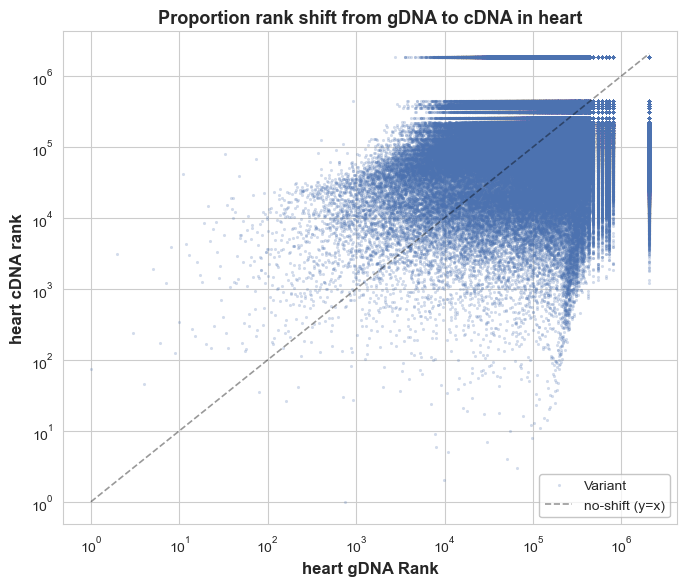

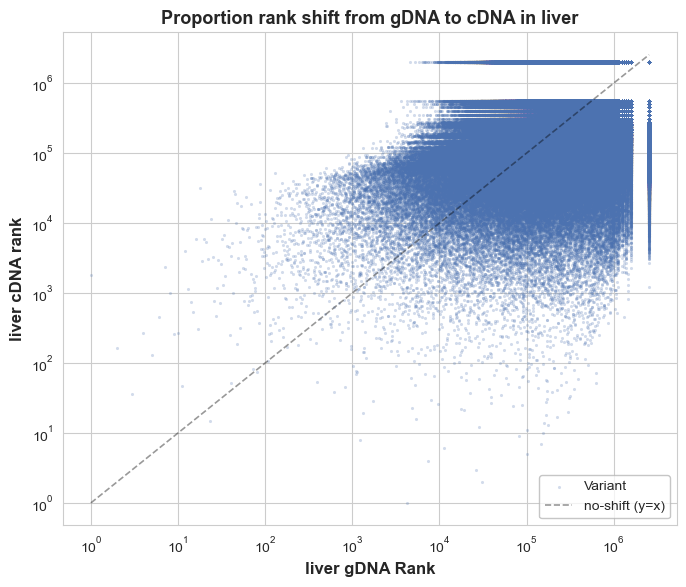

In [368]:
for tissue in TISSUE:
    rank_shift_between_gDNA_and_cDNA (df_pooled_pivot, tissue, 'Proportion')


## 4. Script
### 4.1. Load CSV Files

In [11]:
%%time
#load long table
df_long = read_csv_file(tables_dir / 'summary', "df_long_combined_biological_technical_rep")

# load pooled table
df_pooled = read_csv_file(tables_dir / 'summary', "df_sample_pooled")

# load pooled pivot table
df_pooled_pivot = read_csv_file(tables_dir / 'summary', "df_pooled_pivot")

CPU times: user 58.7 s, sys: 9.53 s, total: 1min 8s
Wall time: 1min 12s


In [12]:
print ('Long Table')
display (df_long)

print ('Pooled Table')
display (df_pooled)

print ('Pooled Pivot Table')
display (df_pooled_pivot)

Long Table


,AA_sequence,Sample,Sex,Mouse_ID,Tissue,Extraction_type,Count,Proportion,Cum_prop,Log2_enrichment,Pseudo_input,Pseudo,Log2_enrich_gDNA_to_cDNA,Replicate
0,AAAAAAA,cDNA_heart_f1,female,f1,heart,cDNA,0.094245,1.414625e-08,1.414625e-08,-2.653285,0,1,0.0,biological
1,AAAAAAD,cDNA_heart_f1,female,f1,heart,cDNA,0.094245,1.414625e-08,2.829250e-08,-5.622911,0,1,0.0,biological
2,AAAAAAE,cDNA_heart_f1,female,f1,heart,cDNA,0.094245,1.414625e-08,4.243875e-08,-1.653285,0,1,0.0,biological
3,AAAAAAG,cDNA_heart_f1,female,f1,heart,cDNA,0.094245,1.414625e-08,5.658500e-08,-4.068322,0,1,0.0,biological
4,AAAAAAN,cDNA_heart_f1,female,f1,heart,cDNA,0.094245,1.414625e-08,7.073125e-08,-2.068322,0,1,0.0,biological
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99089900,EEEGTGG,gDNA_liver_PCR_rep,male,m2,liver,gDNA,0.080694,1.399334e-08,5.413822e-01,-9.098128,0,1,NaN,technical
99089901,GDEEVGG,gDNA_liver_PCR_rep,male,m2,liver,gDNA,0.080694,1.399334e-08,6.739870e-01,-9.114679,0,1,NaN,technical
99089902,DDDDDET,gDNA_liver_PCR_rep,male,m2,liver,gDNA,0.080694,1.399334e-08,1.833632e-01,-9.141850,0,1,NaN,technical
99089903,EVAAADG,gDNA_liver_PCR_rep,male,m2,liver,gDNA,0.080694,1.399334e-08,5.921251e-01,-9.270517,0,1,NaN,technical


Pooled Table


,AA_sequence,Tissue,Extraction_type,Proportion,Log2_enrichment,Log2_enrich_gDNA_to_cDNA,Pseudo_input,Pseudo,n_tissue_samples_present
0,KGDKTKA,liver,cDNA,3.543119e-04,11.186646,10.128364,0,0,6
1,GDKAPGV,liver,cDNA,1.243831e-03,10.690250,8.043095,1,0,6
2,GRHEDGG,liver,cDNA,1.341958e-04,10.337689,8.832518,1,0,6
3,ADGVTGK,liver,cDNA,8.402724e-05,10.197507,8.401431,1,0,6
4,AVAEVEK,liver,cDNA,7.420607e-04,9.957054,8.541326,1,0,6
...,...,...,...,...,...,...,...,...,...
13468405,DEAEDEG,heart,cDNA,8.562416e-08,-10.141046,-6.798321,0,5,1
13468406,DDDDAVG,heart,cDNA,1.414625e-08,-10.198893,-8.354799,0,6,0
13468407,GDEDTGG,liver,cDNA,2.910036e-07,-10.201768,-9.798562,0,5,1
13468408,DDDDAAD,heart,cDNA,1.414625e-08,-10.460640,-7.056782,0,6,0


Pooled Pivot Table


,AA_sequence,Tissue,Log2_enrich_gDNA_to_cDNA_cDNA,Log2_enrichment_cDNA,Log2_enrichment_gDNA,Proportion_cDNA,Proportion_gDNA
0,AAAAAAA,heart,8.008566e-17,-2.653285,-2.653285,1.414625e-08,1.414625e-08
1,AAAAAAA,liver,2.402570e-16,-2.657053,-2.657053,1.406868e-08,1.406868e-08
2,AAAAAAD,heart,8.008566e-17,-5.622911,-5.622911,1.414625e-08,1.414625e-08
3,AAAAAAD,liver,-5.178285e+00,-5.626680,-0.448394,1.406868e-08,8.028154e-07
4,AAAAAAE,heart,8.008566e-17,-1.653285,-1.653285,1.414625e-08,1.414625e-08
...,...,...,...,...,...,...,...
6734200,YYWVDAA,liver,2.402570e-16,-1.072091,-1.072091,1.406868e-08,1.406868e-08
6734201,YYXDVEE,heart,-5.922911e-01,-0.068322,0.523969,1.414625e-08,3.947544e-08
6734202,YYXGDGP,liver,5.817339e-01,0.509643,-0.072091,3.807617e-08,1.406868e-08
6734203,YYYEAAG,liver,5.817339e-01,0.509643,-0.072091,3.807617e-08,1.406868e-08


### 4.2. Extract information from table

In [13]:
SAMPLE, EXT, TISSUE, SEX, MOUSE_ID = extract_info(
    df_long, 
    'Sample', 
    'Extraction_type',
    "Tissue", 
    'Sex', 
    'Mouse_ID'
)

In [14]:
display (SAMPLE, EXT, TISSUE, SEX, MOUSE_ID)

['cDNA_heart_f1',
 'cDNA_heart_f2',
 'cDNA_heart_f3',
 'cDNA_heart_m1',
 'cDNA_heart_m2',
 'cDNA_heart_m3',
 'cDNA_liver_PCR_rep',
 'cDNA_liver_cDNA_rep',
 'cDNA_liver_ex_rep',
 'cDNA_liver_f1',
 'cDNA_liver_f2',
 'cDNA_liver_f3',
 'cDNA_liver_m1',
 'cDNA_liver_m2',
 'cDNA_liver_m3',
 'gDNA_heart_f1',
 'gDNA_heart_f2',
 'gDNA_heart_f3',
 'gDNA_heart_m1',
 'gDNA_heart_m2',
 'gDNA_heart_m3',
 'gDNA_liver_PCR_rep',
 'gDNA_liver_ex_rep',
 'gDNA_liver_f1',
 'gDNA_liver_f2',
 'gDNA_liver_f3',
 'gDNA_liver_m1',
 'gDNA_liver_m2',
 'gDNA_liver_m3']

['cDNA', 'gDNA']

['heart', 'liver']

['female', 'male']

['f1', 'f2', 'f3', 'm1', 'm2', 'm3']

In [15]:
# Sort different file names in extraction and biological or technical Replicates
DICT_NAMES = sort_file_names (SAMPLE)

In [16]:
DICT_NAMES

{'gDNA': {'heart': {'biological': ['gDNA_heart_f1',
    'gDNA_heart_f2',
    'gDNA_heart_f3',
    'gDNA_heart_m1',
    'gDNA_heart_m2',
    'gDNA_heart_m3'],
   'technical': []},
  'liver': {'biological': ['gDNA_liver_f1',
    'gDNA_liver_f2',
    'gDNA_liver_f3',
    'gDNA_liver_m1',
    'gDNA_liver_m2',
    'gDNA_liver_m3'],
   'technical': ['gDNA_liver_PCR_rep', 'gDNA_liver_ex_rep']}},
 'cDNA': {'heart': {'biological': ['cDNA_heart_f1',
    'cDNA_heart_f2',
    'cDNA_heart_f3',
    'cDNA_heart_m1',
    'cDNA_heart_m2',
    'cDNA_heart_m3'],
   'technical': []},
  'liver': {'biological': ['cDNA_liver_f1',
    'cDNA_liver_f2',
    'cDNA_liver_f3',
    'cDNA_liver_m1',
    'cDNA_liver_m2',
    'cDNA_liver_m3'],
   'technical': ['cDNA_liver_PCR_rep',
    'cDNA_liver_cDNA_rep',
    'cDNA_liver_ex_rep']}}}

### 4.3. Load tissue/ext specific librarys

In [17]:
%%time
# Load tissue specific library 
dict_library = {}
for tissue in TISSUE:
    df = read_csv_file(tables_dir/tissue, f'df_{tissue}_input_library')
    dict_library[tissue] = df

# Load raw library  for corr with special library
df_raw_input =  read_csv_file(tables_dir, 'df_input_lib_raw')

CPU times: user 1.87 s, sys: 187 ms, total: 2.05 s
Wall time: 2.14 s


### 4.4. Chapter 1: Comparison between input and samples regarding proportion

#### 4.4.1. Histogram with am proportion with Hue = Sample


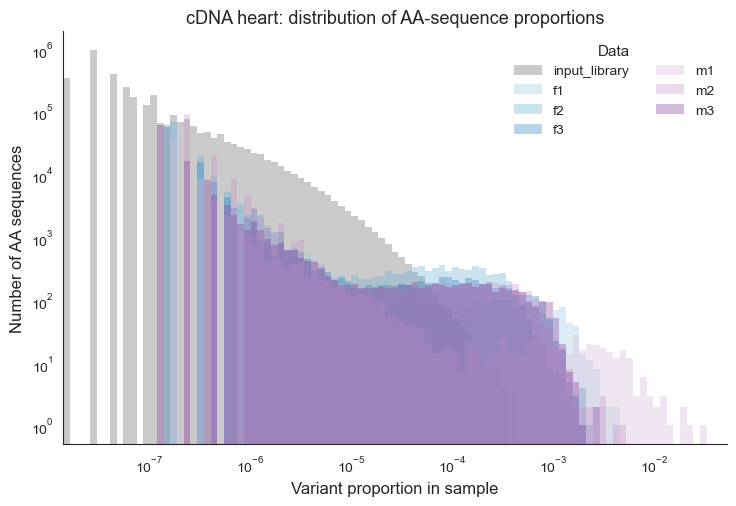

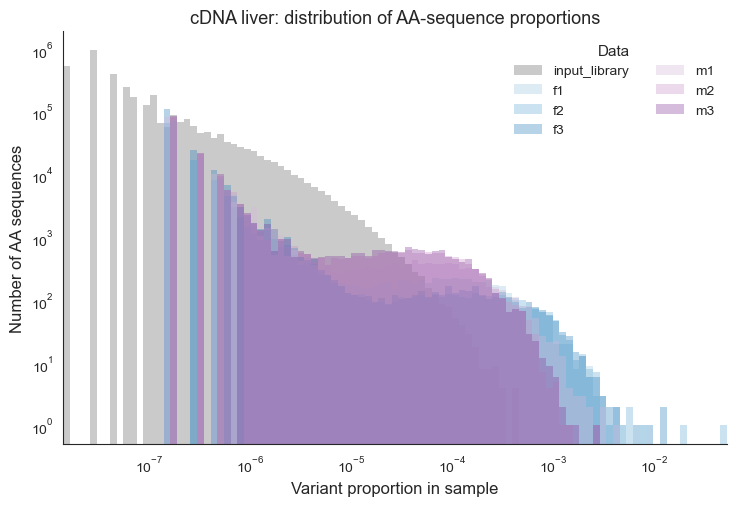

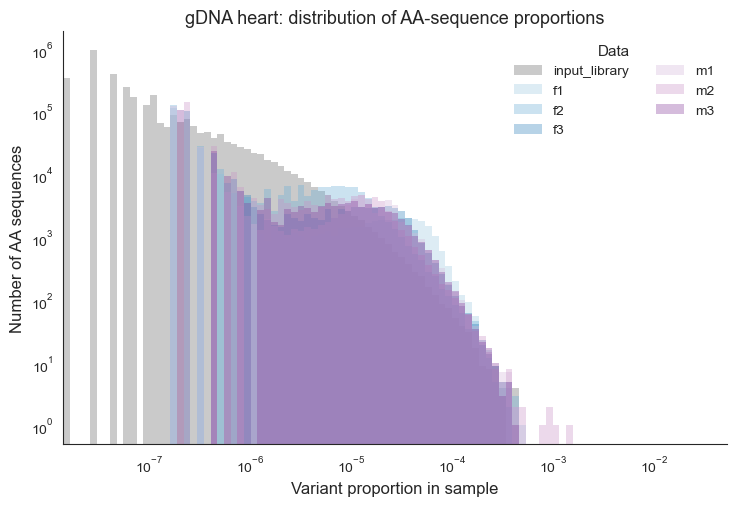

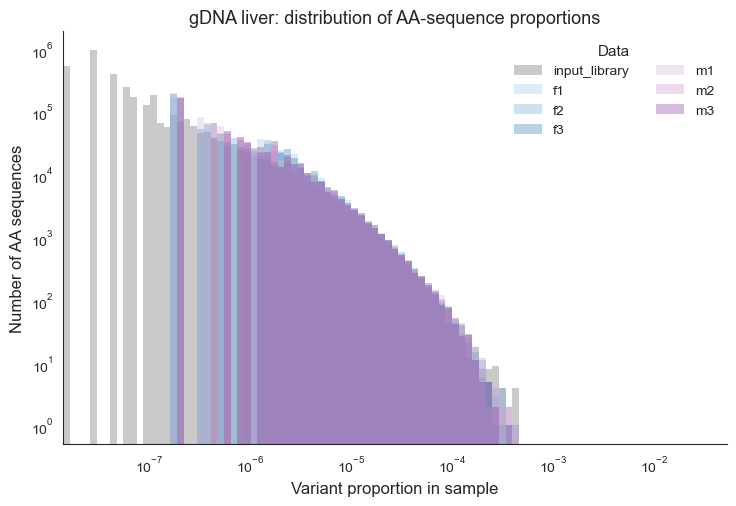

CPU times: user 37 s, sys: 8.6 s, total: 45.6 s
Wall time: 49.3 s


In [20]:
%%time
for ext, tissue in product (EXT, TISSUE):
    distribution_histogram (
        df_long, 
        tissue, 
        ext, 
        column = 'Proportion', 
        replicate = 'biological', 
        no_pseudo=True, 
        legend = True, 
        title = True, 
        save = False, 
        output_path = figures_dir/'1_proportion'/'1_histogram'
    )


#### 4.4.2. ECDF Proportion with samples and input

In [ ]:
for ext, tissue in product (EXT, TISSUE):
    distribution_ecdf(
        table=df_long,
        tissue=tissue,
        extraction=ext,
        column="Proportion",
        replicate="biological",
        no_pseudo=False,
        save = False,
        output_path = figures_dir/'1_proportion'/'2_ECDF_proportion'     
    )

#### 4.4.3. Venn2 Input vs mean proportion in sample

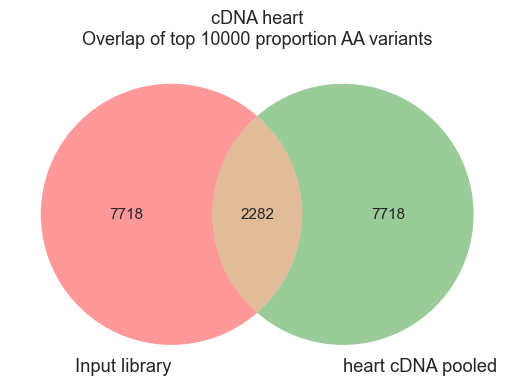

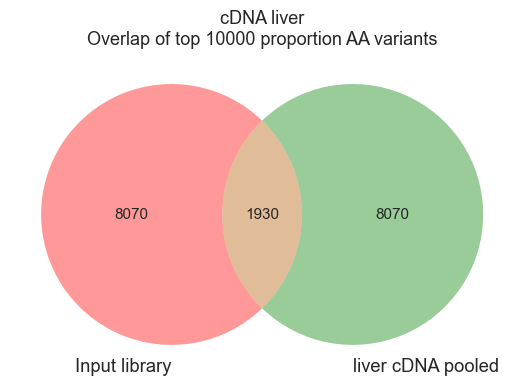

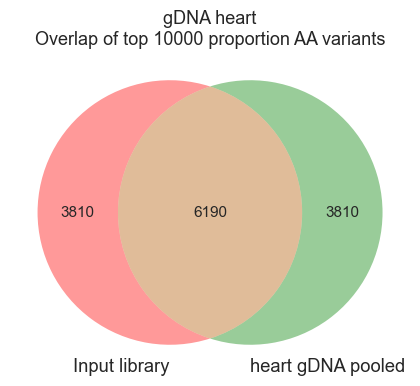

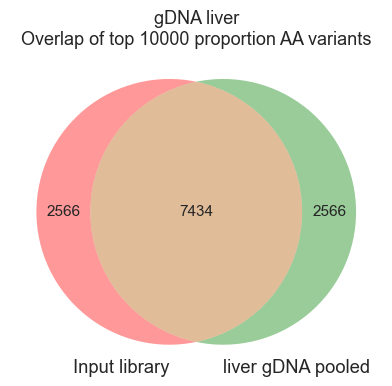

In [77]:
for ext, tissue in product (EXT, TISSUE):
    venn2_ntop_AA (
        df_pooled, 
        tissue, ext, 
        10000, 
        title=True, 
        save = True,
        output_path =  figures_dir/'1_proportion'/'3_Venn2'
    )

In [ ]:
number = [10, 100, 1000, 10000]
for ext, tissue, n in product (EXT, TISSUE, number):
    venn2_ntop_AA (df_pooled, tissue, ext, n)

### 4.5. Chapter 2: Comparison between biological replicates in enrichment
#### 4.5.1 ECDF Log2 distribution between samples

In [ ]:
%%time
for tissues, exts in product (TISSUE, EXT):
    distribution_ecdf (
        table = df_long, 
        tissue = tissues, 
        extraction = exts, 
        column = 'Log2_enrichment', 
        replicate = 'biological', 
        n_tissues=False, 
        save = True, 
        output_path = figures_dir/'2_enrichment'/'1_ECDF'/'with_pseudo'
    );

In [ ]:
%%time
for tissues, exts in product (TISSUE, EXT):
    distribution_ecdf (
        table = df_long, 
        tissue = tissues,
        extraction = exts, 
        column = 'Log2_enrichment', 
        replicate = 'biological', 
        no_pseudo=True, 
        save = True, 
        output_path = figures_dir/'2_enrichment'/'1_ECDF'/'no_pseudo'
    );

### 4.6. Chapter 3: Comparison functional selection between RNA and DNA samples

#### 4.6.1. Violin plot mean between biological Replicate

In [ ]:
n_sample = [0,1,2,3,4,5,6]
for n in n_sample:
    violin_enrichment_per_type_test (
        df_pooled, 
        violin = True, 
        box = False, 
        scatter_dots=True, 
        n_samples=n, 
        save = True, 
        output_path=figures_dir/'3_gDNA_vs_cDNA'/'1_violin', 
        file_name=f'violin_log2_enrichment_variant_in_min_{n}_samples.png'
    )

    

#### 4.6.2. KDE plot for liver and heart (DNA and RNA in one plot, x = enrichment, y = n variant)

In [ ]:
for tissue in TISSUE:
    kde_gDNA_vs_cDNA (
        df_pooled, 
        tissue, 
        column = 'Log2_enrichment', 
        n_samples = 3, 
        save = False, 
        output_path=figures_dir/'3_gDNA_vs_cDNA'/'2_KDE'
    )

In [ ]:
n = [0,1,2,3,4,5,6]
for tissue, n_p in product (TISSUE, n):
    kde_gDNA_vs_cDNA (
        df_pooled, 
        tissue, 
        column = 'Log2_enrichment', 
        n_samples = n_p, 
        save = True, 
        output_path=figures_dir/'3_gDNA_vs_cDNA'/'2_KDE'
    )

#### 4.6.3. Venn2 plot with top 10000 enrichment
    - to show already the selection difference between biological step and tissue

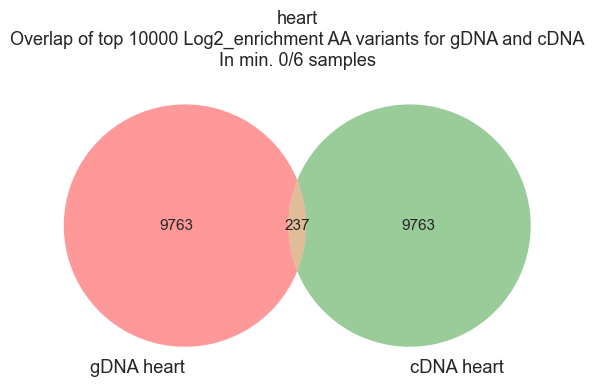

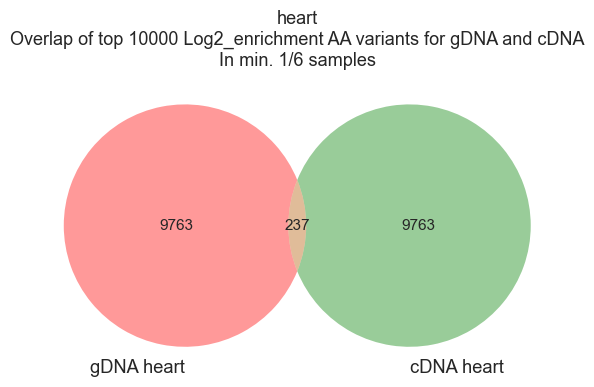

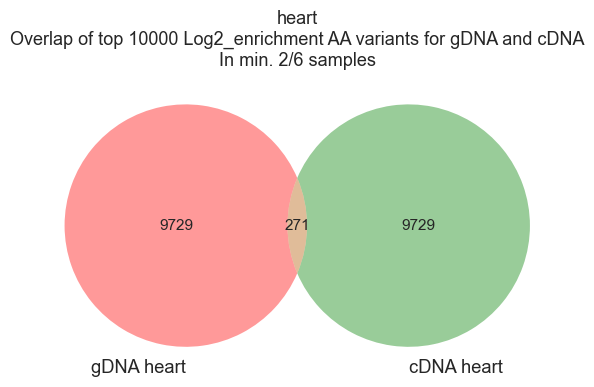

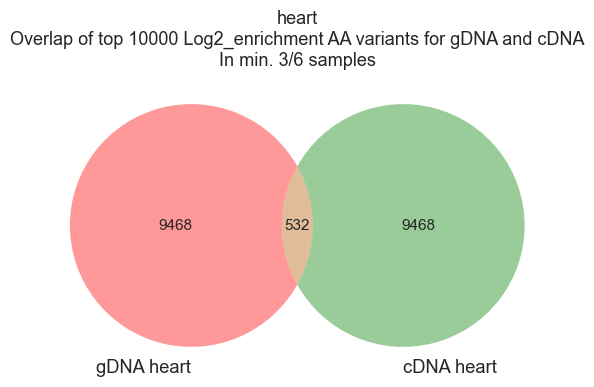

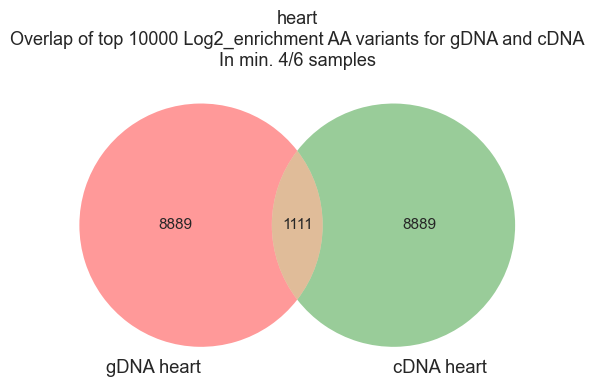

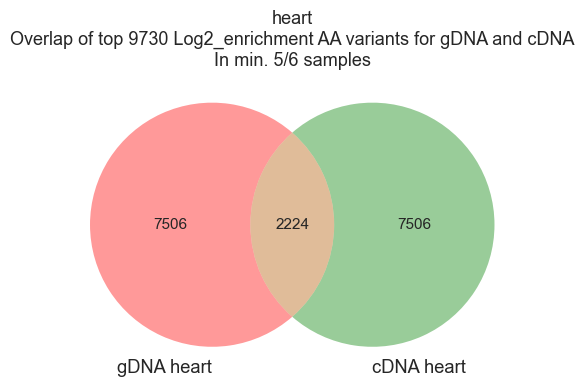

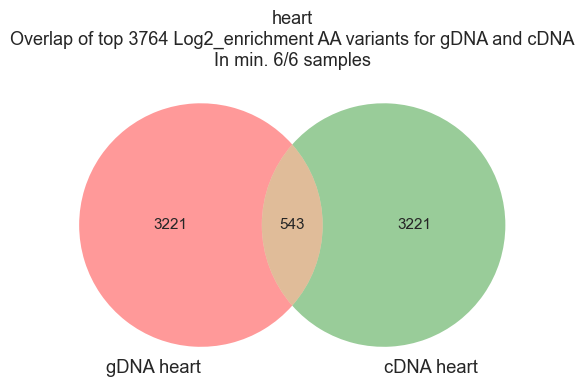

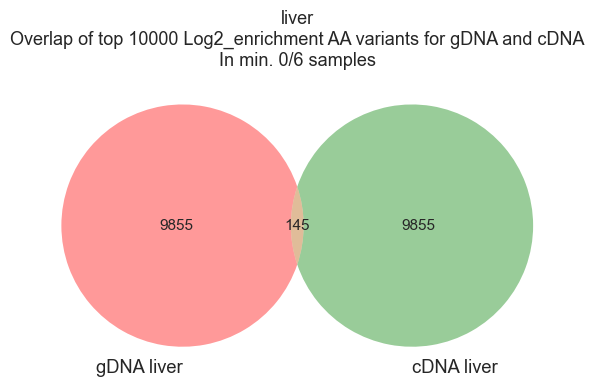

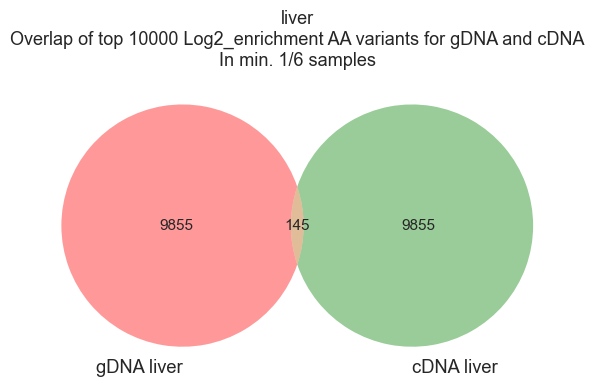

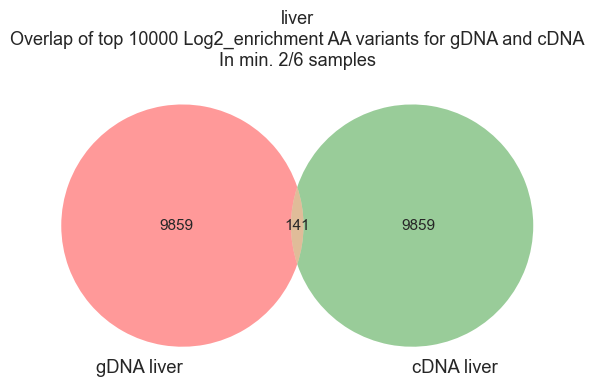

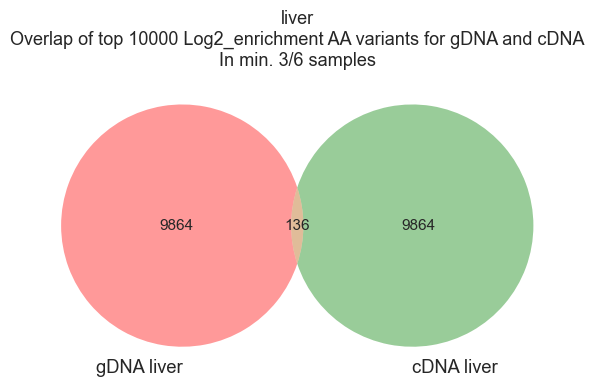

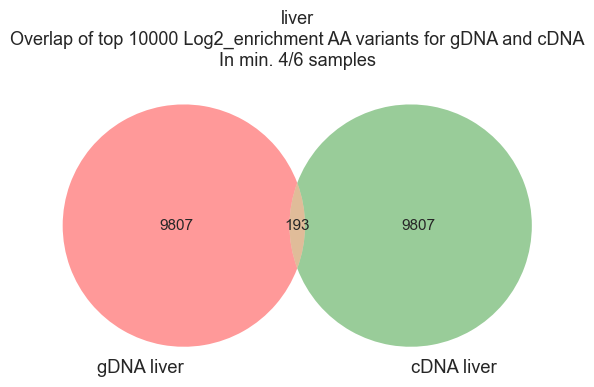

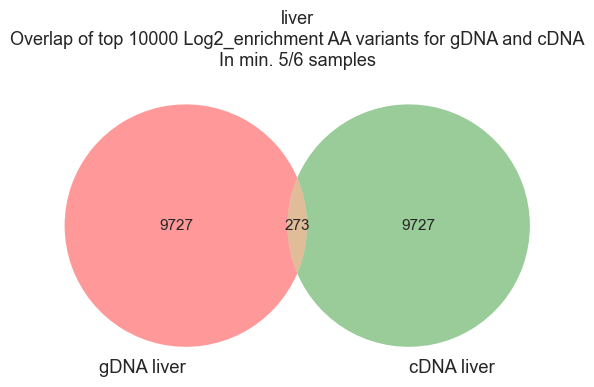

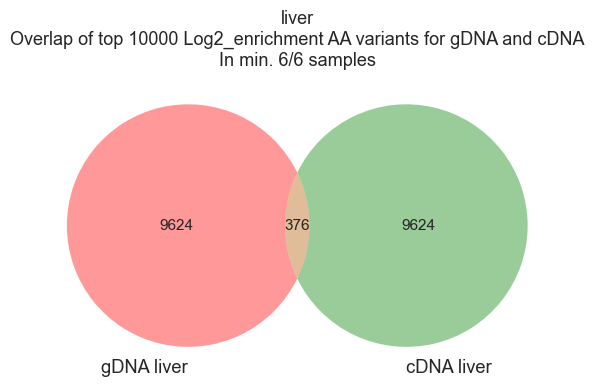

In [148]:
number = list(range(0, 7, 1))

for tissue, n in product (TISSUE, number):
    venn2_top_enrichment_variants (
        df_pooled,
        tissue,
        10000,
        n_samples=n,
        save = True,
        output_path=figures_dir/'3_gDNA_vs_cDNA'/'3_Venn2_log2'
    )

#### 4.6.4. Diagramm of Venn2 plot overlap between top 1 and all variants

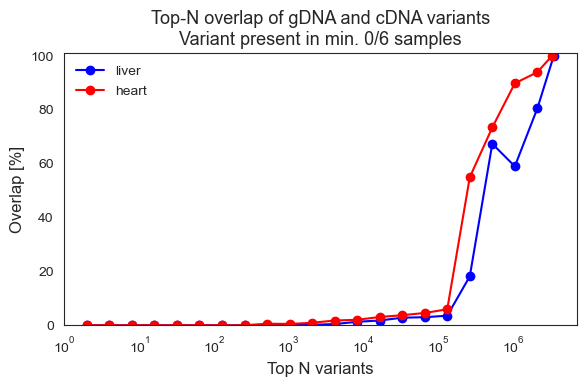

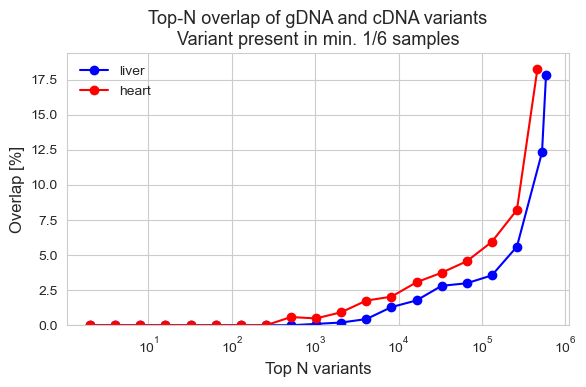

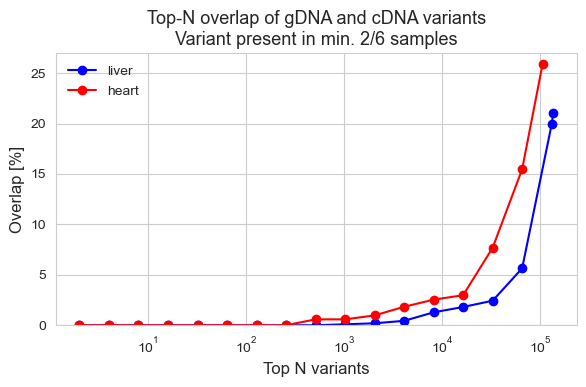

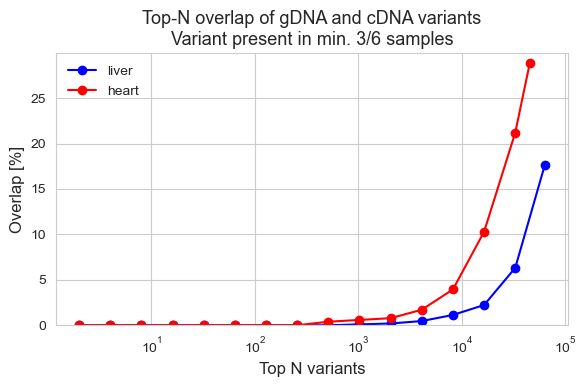

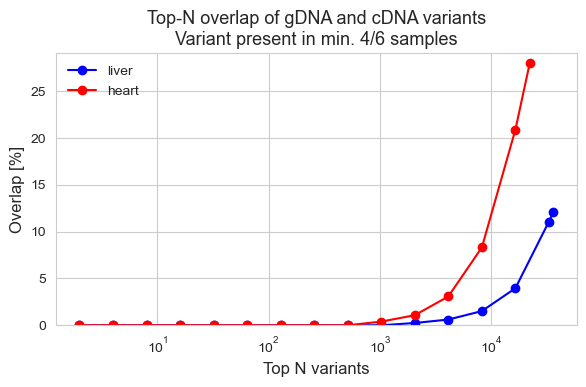

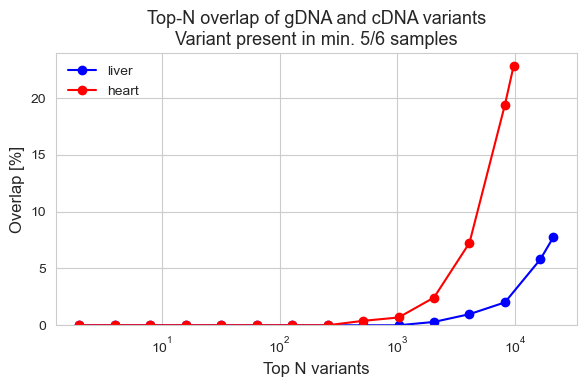

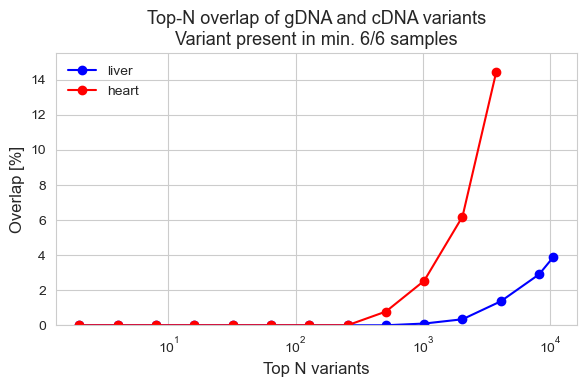

In [342]:
number = list(range(0,7,1))
for n in number:
    Diagram_for_overlap_log2 (
        table=df_pooled, 
        tissues=['liver', 'heart'], 
        n_samples=n, 
        save = False, 
        output_path=figures_dir/'3_gDNA_vs_cDNA'/'4_Diagram_of_overlap'
    )

#### 4.6.5. Rank_shift scatter plot

### 4.7. Chapter 4: Log2 enrichment from gDNA level to cDNA level

#### 4.7.1. ECDF Log2_enrichment from gDNA to cDNA between samples

In [ ]:
df = df_long.loc[
    (df_long['Pseudo'] == 0) & 
    (df_long['Extraction_type'] == 'cDNA')
]

for tissue in TISSUE:  
    distribution_ecdf(
            table=df,
            tissue=tissue,
            extraction= 'cDNA',
            column="Log2_enrich_gDNA_to_cDNA",
            replicate="biological",
            save = True,
            output_path = figures_dir/'4_Log2_enrichment_gDNA_to_cDNA'/'1_ECDF_enrichment'     
        )

#### 4.7.2. AA_position heatmap for Log2_enrichment_gDNA_to_cDNA

### 4.8. Chapter 5: Validation of reproducibility between biological and technical replicates

#### 4.8.1. Scatterplots

##### 4.8.1.1. Biological replicates

##### 4.8.1.2. technical replicates

##### 4.8.1.3. sex

#### 4.8.2. Corr matrix (Sample -> Mouse_ID -> Sex) (sns.clustermap?)

#### 4.8.3. violin plot of correlations (technical rep | biological rep | sex)


#### 4.8.4. Leave one out scatter plot (shows that noise can be reduced by averaging)


#### 4.8.5. Randomize one mouse and use it in correlation matrix

## 99. Suplement Figures

### 99.1. Correlation between raw input Library and tissue libraries

In [ ]:
input_library

In [ ]:
tissue = 'liver'
extraction = 'cDNA'

tissue_specific = dict_library[tissue][extraction].sort_values('AA_sequence', ascending = True).copy()
input_library = df_raw_input.sort_values('AA_sequence', ascending = True).copy()
input_library['Proportion'] = input_library['Count']/sum(input_library['Count'])

# merge über AA_sequence
merged = tissue_specific.merge(
    input_library[['AA_sequence', 'Proportion']],
    on='AA_sequence',
    how='inner',
    suffixes=('_tissue', '_input')
)

merged = merged.dropna(subset=['Proportion_tissue', 'Proportion_input'])

# Pearson correlation
pearson_corr = stats.pearsonr(
    merged['Proportion_tissue'],
    merged['Proportion_input']
)
pearson_corr

sns.scatterplot(data = merged, x = 'Proportion_input', y = 'Proportion_input');
sns.axline(slope = float(pearson_corr[0]), color = 'b')



In [ ]:
df_wide = (
    df_pooled.pivot_table(
        index=["AA_sequence", "Tissue"],
        columns="Extraction_type",
        values="Log2_enrichment",
        aggfunc="first"
    )
)

df_wide = df_wide.rename(columns={
    "gDNA": "Log2_enrichment_gDNA",
    "cDNA": "Log2_enrichment_cDNA"
}).reset_index()

df_wide

In [ ]:
sns.jointplot(
    data=df_wide,
    x="Log2_enrichment_gDNA",
    y="Log2_enrichment_cDNA",
    hue="Tissue",
    kind="scatter",
    marginal_kws=dict(common_norm=False),
    alpha=0.4
)